In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("Libraries loaded successfully")

Libraries loaded successfully


In [ ]:
# Load data and first look
df = pd.read_csv('D:\POWERBI\Attrition_predictor\data\HR-Employee-Attrition.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (1470, 35)

Columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

First 5 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Check missing values and data types
print("Missing values:\n", df.isnull().sum().sum())
print("\nData types:\n", df.dtypes.value_counts())
print("\nTarget distribution:")
print(df['Attrition'].value_counts())
print(f"\nAttrition rate: {df['Attrition'].value_counts(normalize=True)['Yes']*100:.1f}%")

Missing values:
 0

Data types:
 int64    26
str       9
Name: count, dtype: int64

Target distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition rate: 16.1%


In [ ]:
# Drop useless columns and encode target
cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df = df.drop(cols_to_drop, axis=1)

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

print("Dropped:", cols_to_drop)
print("New shape:", df.shape)
print("Attrition encoded — 1=Left, 0=Stayed")

Dropped: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
New shape: (1470, 31)
Attrition encoded — 1=Left, 0=Stayed


C:\Users\Thejashwini\AppData\Local\Temp\ipykernel_21596\2881247752.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,1].boxplot([df[df['Attrition']==0]['MonthlyIncome'],


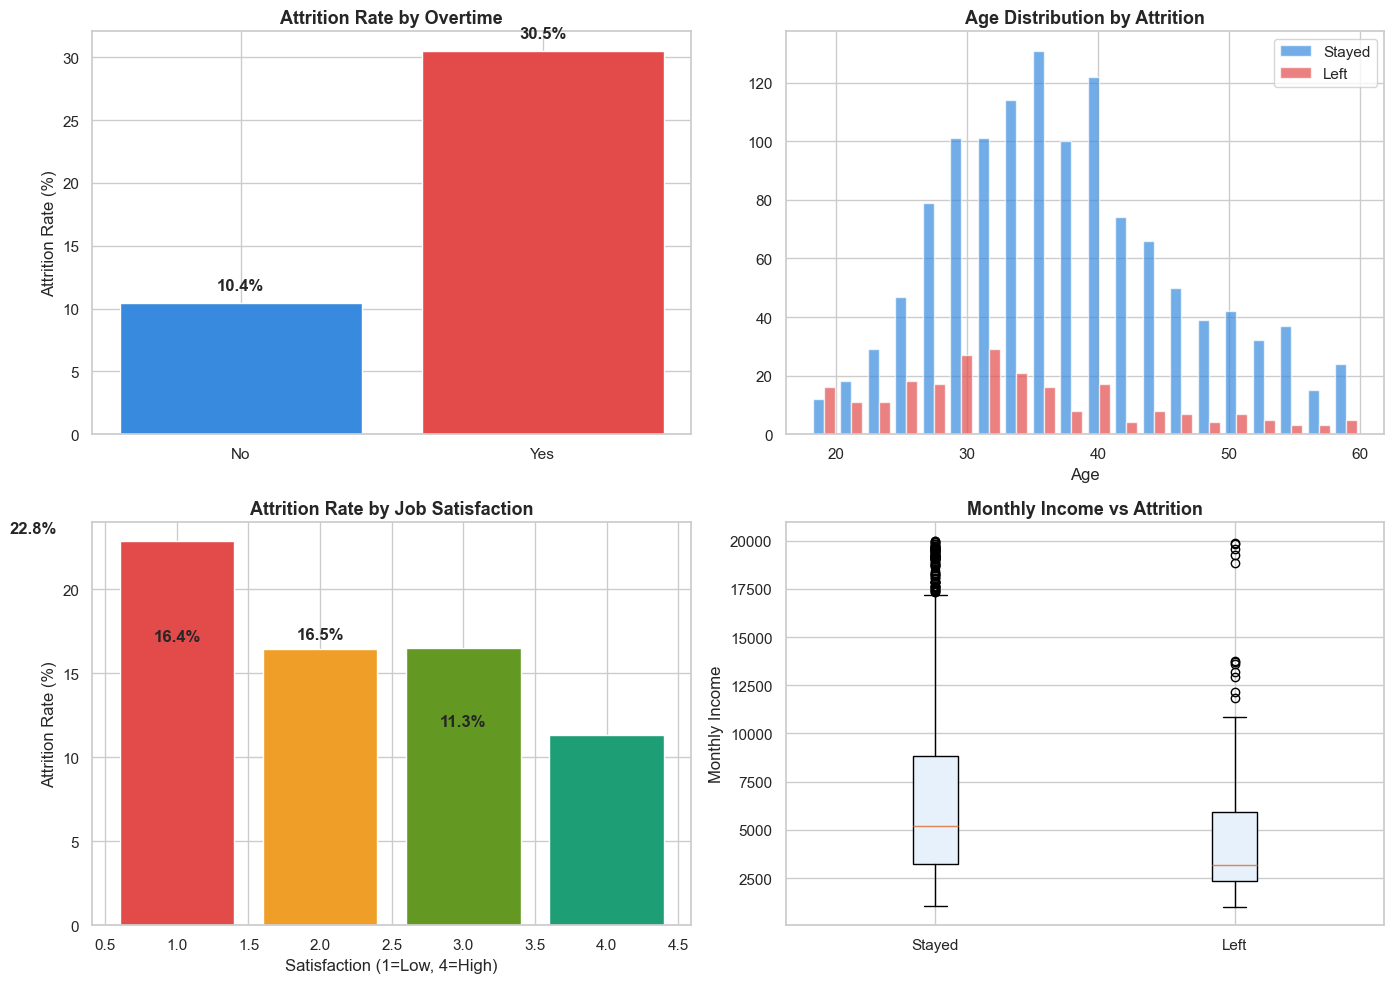

Chart saved as eda_plots.png


In [ ]:
# Attrition rate by key categories
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Overtime
overtime_rate = df.groupby('OverTime')['Attrition'].mean() * 100
axes[0,0].bar(overtime_rate.index, overtime_rate.values, color=['#378ADD','#E24B4A'])
axes[0,0].set_title('Attrition Rate by Overtime', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(overtime_rate.values):
    axes[0,0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# Age distribution
axes[0,1].hist([df[df['Attrition']==0]['Age'], df[df['Attrition']==1]['Age']],
               bins=20, label=['Stayed','Left'], color=['#378ADD','#E24B4A'], alpha=0.7)
axes[0,1].set_title('Age Distribution by Attrition', fontsize=13, fontweight='bold')
axes[0,1].set_xlabel('Age')
axes[0,1].legend()

# Job Satisfaction
sat_rate = df.groupby('JobSatisfaction')['Attrition'].mean() * 100
axes[1,0].bar(sat_rate.index, sat_rate.values, color=['#E24B4A','#EF9F27','#639922','#1D9E75'])
axes[1,0].set_title('Attrition Rate by Job Satisfaction', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Satisfaction (1=Low, 4=High)')
axes[1,0].set_ylabel('Attrition Rate (%)')
for i, v in enumerate(sat_rate.values):
    axes[1,0].text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')

# Monthly Income
axes[1,1].boxplot([df[df['Attrition']==0]['MonthlyIncome'],
                   df[df['Attrition']==1]['MonthlyIncome']],
                  labels=['Stayed','Left'],
                  patch_artist=True,
                  boxprops=dict(facecolor='#E6F1FB'))
axes[1,1].set_title('Monthly Income vs Attrition', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Monthly Income')

plt.tight_layout()
plt.savefig('../eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as eda_plots.png")

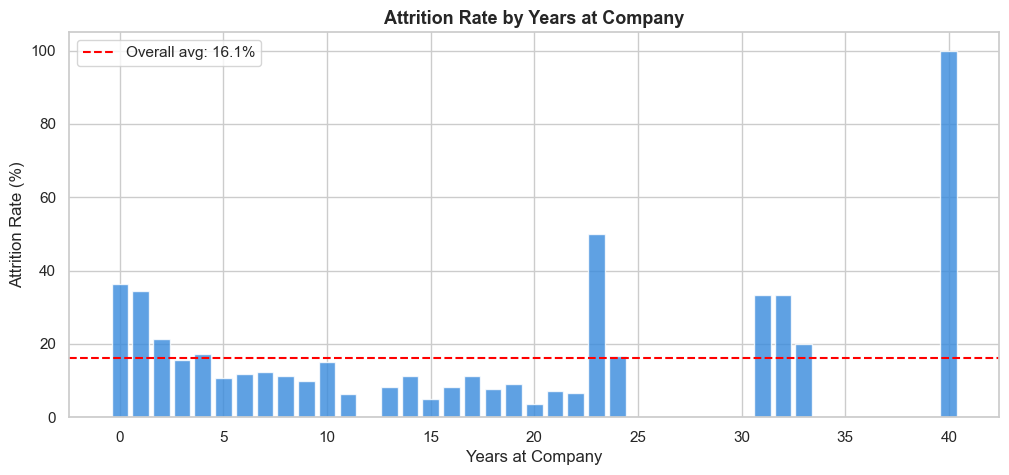

In [ ]:
# Years at company analysis
fig, ax = plt.subplots(figsize=(12, 5))
years_rate = df.groupby('YearsAtCompany')['Attrition'].mean() * 100
ax.bar(years_rate.index, years_rate.values, color='#378ADD', alpha=0.8)
ax.set_title('Attrition Rate by Years at Company', fontsize=13, fontweight='bold')
ax.set_xlabel('Years at Company')
ax.set_ylabel('Attrition Rate (%)')
ax.axhline(y=df['Attrition'].mean()*100, color='red',
           linestyle='--', label=f'Overall avg: {df["Attrition"].mean()*100:.1f}%')
ax.legend()
plt.savefig('../years_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

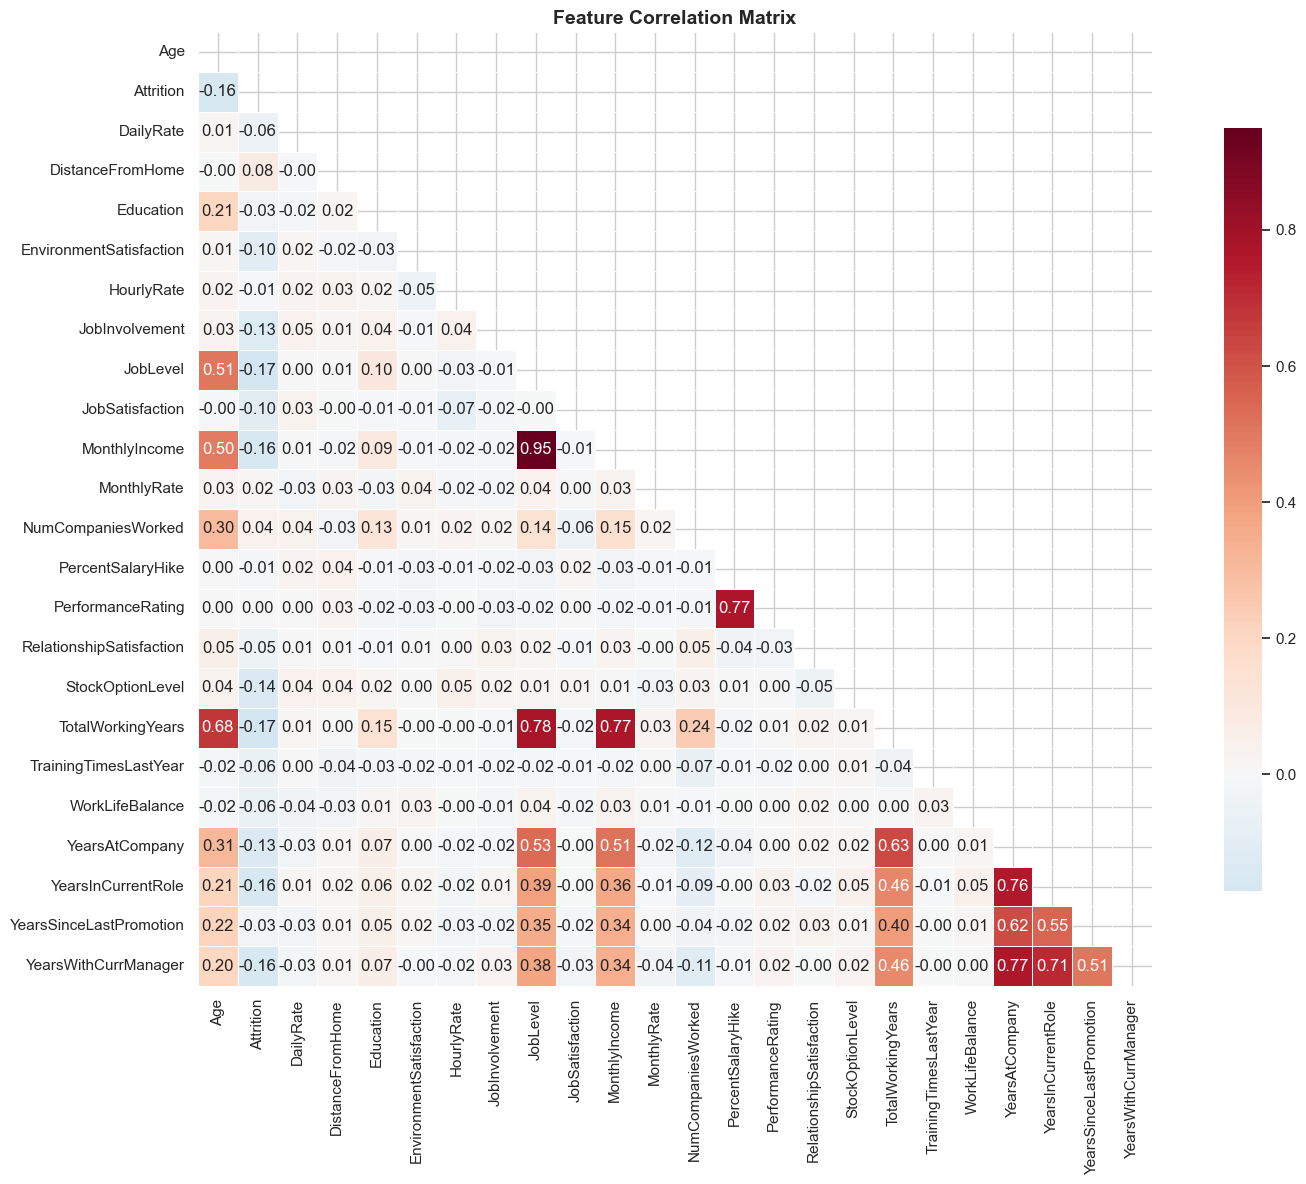

In [ ]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(numeric_df.corr(), dtype=bool))
sns.heatmap(numeric_df.corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#  Key findings summary
overtime_yes = df[df['OverTime']=='Yes']['Attrition'].mean()*100
overtime_no  = df[df['OverTime']=='No']['Attrition'].mean()*100
median_stayed = df[df['Attrition']==0]['YearsAtCompany'].median()
median_left   = df[df['Attrition']==1]['YearsAtCompany'].median()
low_sat  = df[df['JobSatisfaction']==1]['Attrition'].mean()*100
high_sat = df[df['JobSatisfaction']==4]['Attrition'].mean()*100
avg_income_stayed = df[df['Attrition']==0]['MonthlyIncome'].mean()
avg_income_left   = df[df['Attrition']==1]['MonthlyIncome'].mean()

print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)
print(f"Overall attrition rate      : {df['Attrition'].mean()*100:.1f}%")
print(f"Overtime → attrition rate   : {overtime_yes:.1f}% vs {overtime_no:.1f}% (no overtime)")
print(f"Median tenure — stayed      : {median_stayed:.0f} years")
print(f"Median tenure — left        : {median_left:.0f} years")
print(f"Low satisfaction attrition  : {low_sat:.1f}%")
print(f"High satisfaction attrition : {high_sat:.1f}%")
print(f"Avg income — stayed         : ${avg_income_stayed:,.0f}")
print(f"Avg income — left           : ${avg_income_left:,.0f}")
print("=" * 50)

KEY FINDINGS
Overall attrition rate      : 16.1%
Overtime → attrition rate   : 30.5% vs 10.4% (no overtime)
Median tenure — stayed      : 6 years
Median tenure — left        : 3 years
Low satisfaction attrition  : 22.8%
High satisfaction attrition : 11.3%
Avg income — stayed         : $6,833
Avg income — left           : $4,787
